Data Splitting

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name = "MedHouseValue")

df = X.copy()
df["target"] = y

display(df)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


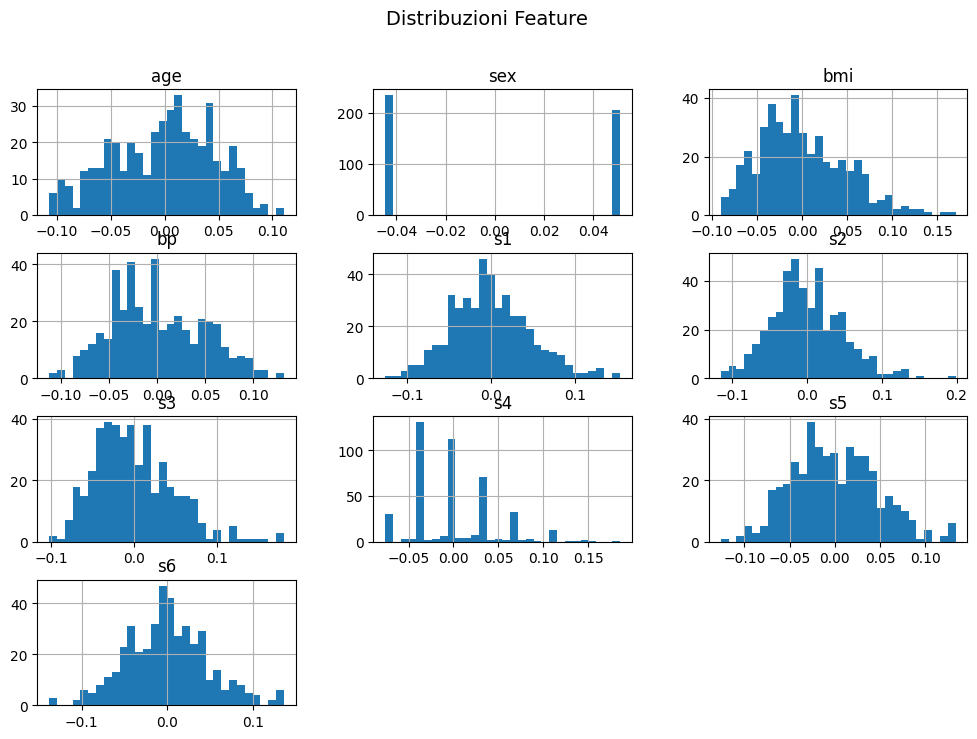

In [3]:
# andiamo a vedere gli istogrammi delle distribuzioni delle feature

X.hist(bins=30, figsize=(12,8))
plt.suptitle("Distribuzioni Feature", fontsize = 14)
plt.show()

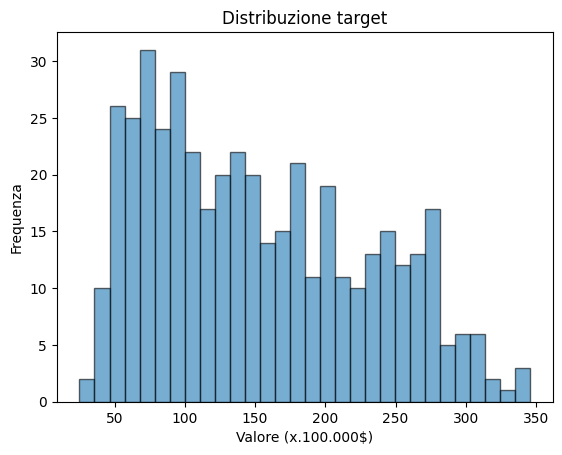

In [4]:
plt.hist(y, bins=30, edgecolor="black", alpha = 0.6)
plt.title("Distribuzione target")
plt.xlabel("Valore (x.100.000$)")
plt.ylabel("Frequenza")
plt.show()

In [5]:
# dividiamo il dataset in test set e training set, per evitare che il modello sia influenzato dal data leakage

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train Set:\t{X_train.shape}")
print(f"Test Set:\t{X_test.shape}")


Train Set:	(353, 10)
Test Set:	(89, 10)


In [6]:
# applichiamo lo scaling dopo la suddivisione

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"MSE TRAINING SET:\t{mse_train:.4}")
print(f"R2 TRAINING SET:\t{r2_train:.4}")
print(f"MSE TEST SET:\t{mse_test:.4}")
print(f"R2 TEST SET:\t{r2_test:.4}")

MSE TRAINING SET:	2.869e+05%
R2 TRAINING SET:	0.5279
MSE TEST SET:	2.973e+05%
R2 TEST SET:	0.4389


In [9]:
# anche in questo caso il modello è stato allenato bene perché la differenza tra train è test è molto simile
